In [1]:
# Importing required library
import pandas as pd

# Loading the dataset
df = pd.read_csv("all_tickets_processed_improved_v3.csv")

# Display first 5 rows
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [2]:
# Display dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Count unique ticket categories
print("\nTicket Categories:")
print(df['Topic_group'].value_counts())

Dataset Shape: (47837, 2)

Column Names:
Index(['Document', 'Topic_group'], dtype='object')

Missing Values:
Document       0
Topic_group    0
dtype: int64

Ticket Categories:
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


In [3]:
# Display one complete ticket text

print(df['Document'][0])

connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead


In [4]:
# Input feature (ticket text)
X = df['Document']

# Target variable (ticket category)
y = df['Topic_group']

# Display first 5 entries
print(X.head())

print("\n")

print(y.head())

0    connection with icon icon dear please setup ic...
1    work experience user work experience user hi w...
2    requesting for meeting requesting meeting hi p...
3    reset passwords for external accounts re expir...
4    mail verification warning hi has got attached ...
Name: Document, dtype: object


0         Hardware
1           Access
2         Hardware
3           Access
4    Miscellaneous
Name: Topic_group, dtype: object


In [5]:
# Import train_test_split function
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display sizes
print("Training Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

Training Data Size: (38269,)
Testing Data Size: (9568,)


In [6]:
# Import TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF object
tfidf = TfidfVectorizer(stop_words='english')

# Convert training text into numerical vectors
X_train_tfidf = tfidf.fit_transform(X_train)

# Convert testing text using learned vocabulary
X_test_tfidf = tfidf.transform(X_test)

# Display shape
print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (38269, 11414)
Testing TF-IDF Shape: (9568, 11414)


In [7]:
# Import Naive Bayes model
from sklearn.naive_bayes import MultinomialNB

# Create model object
model = MultinomialNB()

# Train the model
model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [8]:
# Predict categories for testing data
y_pred = model.predict(X_test_tfidf)

# Display first 10 predictions
print("Predicted Categories:\n")
print(y_pred[:10])

Predicted Categories:

['Hardware' 'Purchase' 'HR Support' 'HR Support' 'Hardware' 'Access'
 'Hardware' 'Internal Project' 'Hardware' 'HR Support']


In [9]:
# Import accuracy score
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Display accuracy
print("Model Accuracy:", accuracy)

Model Accuracy: 0.7313963210702341


In [10]:
# Import classification report
from sklearn.metrics import classification_report

# Display classification report
print(classification_report(y_test, y_pred))

                       precision    recall  f1-score   support

               Access       0.89      0.71      0.79      1455
Administrative rights       1.00      0.16      0.28       342
           HR Support       0.69      0.78      0.74      2107
             Hardware       0.63      0.90      0.74      2760
     Internal Project       0.99      0.36      0.53       451
        Miscellaneous       0.77      0.64      0.70      1400
             Purchase       0.99      0.82      0.90       497
              Storage       0.97      0.55      0.70       556

             accuracy                           0.73      9568
            macro avg       0.87      0.62      0.67      9568
         weighted avg       0.77      0.73      0.72      9568



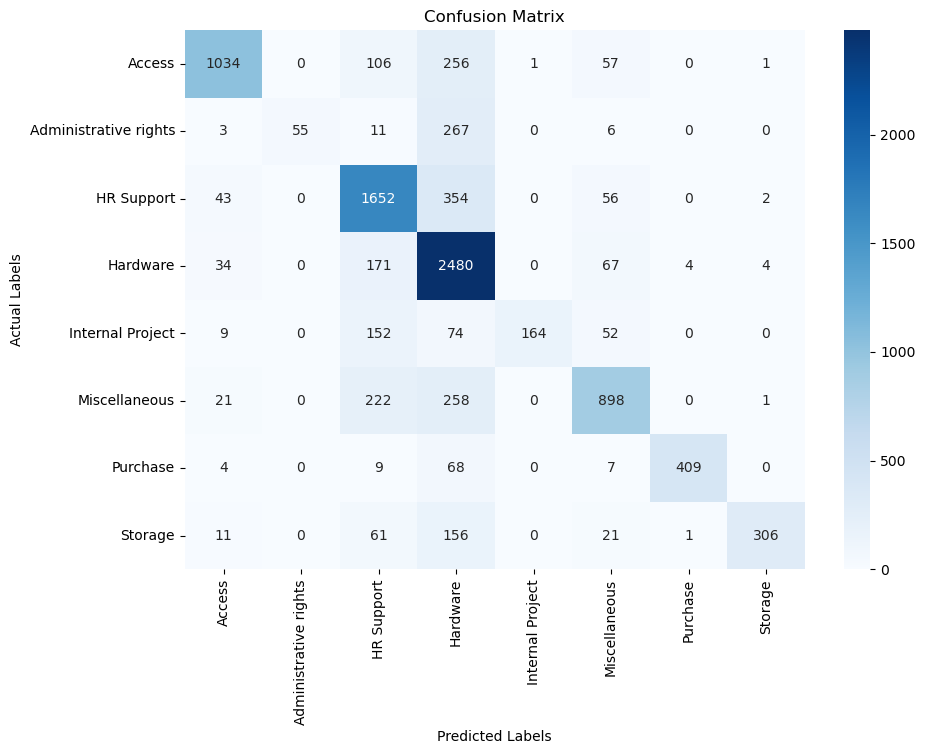

In [11]:
# Import required libraries
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

# Labels and title
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix")

# Display plot
plt.show()

In [12]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

# Train the model
lr_model.fit(X_train_tfidf, y_train)

print("Balanced Logistic Regression model trained successfully!")

Balanced Logistic Regression model trained successfully!


In [13]:
# Predict using Logistic Regression
lr_y_pred = lr_model.predict(X_test_tfidf)

# Display first 10 predictions
print("Predicted Categories:\n")
print(lr_y_pred[:10])

Predicted Categories:

['Hardware' 'Purchase' 'Internal Project' 'HR Support' 'Hardware' 'Access'
 'Hardware' 'Internal Project' 'Hardware' 'HR Support']


In [14]:
# Import accuracy score
from sklearn.metrics import accuracy_score

# Calculate Logistic Regression accuracy
lr_accuracy = accuracy_score(y_test, lr_y_pred)

# Display accuracy
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8391513377926422


In [15]:
# Import classification report
from sklearn.metrics import classification_report

# Display classification report
print(classification_report(y_test, lr_y_pred))

                       precision    recall  f1-score   support

               Access       0.90      0.89      0.89      1455
Administrative rights       0.63      0.90      0.74       342
           HR Support       0.87      0.80      0.83      2107
             Hardware       0.86      0.78      0.82      2760
     Internal Project       0.79      0.92      0.85       451
        Miscellaneous       0.77      0.86      0.81      1400
             Purchase       0.90      0.91      0.90       497
              Storage       0.85      0.93      0.88       556

             accuracy                           0.84      9568
            macro avg       0.82      0.87      0.84      9568
         weighted avg       0.85      0.84      0.84      9568



In [16]:
# Create priority mapping dictionary

priority_map = {
    'Access': 'High',
    'Administrative rights': 'High',
    'Hardware': 'High',
    'HR Support': 'Medium',
    'Internal Project': 'Medium',
    'Storage': 'Medium',
    'Miscellaneous': 'Low',
    'Purchase': 'Low'
}

# Convert predicted categories into priorities

predicted_priorities = [
    priority_map[label]
    for label in lr_y_pred
]

# Display first 10 priorities

print(predicted_priorities[:10])

['High', 'Low', 'Medium', 'Medium', 'High', 'High', 'High', 'Medium', 'High', 'Medium']


In [17]:
# Start infinite loop

while True:

    # Take user input
    user_ticket = input("Enter your support ticket (or type 'exit' to stop): ")

    # Exit condition
    if user_ticket.lower() == 'exit':
        print("System stopped.")
        break

    # Convert input into TF-IDF vector
    ticket_vector = tfidf.transform([user_ticket])

    # Predict category
    predicted_category = lr_model.predict(ticket_vector)[0]

    # Predict priority
    predicted_priority = priority_map[predicted_category]

    # Display results
    print("\nPredicted Category:", predicted_category)
    print("Predicted Priority:", predicted_priority)
    print("-" * 50)

Enter your support ticket (or type 'exit' to stop):  Need access to internal dashboard urgently



Predicted Category: HR Support
Predicted Priority: Medium
--------------------------------------------------


Enter your support ticket (or type 'exit' to stop):  Printer is not responding in office network



Predicted Category: Hardware
Predicted Priority: High
--------------------------------------------------


Enter your support ticket (or type 'exit' to stop):  Unable to apply for leave in HR portal


...


Predicted Category: Storage
Predicted Priority: Medium
--------------------------------------------------


Enter your support ticket (or type 'exit' to stop):  Need assistance regarding office seating arrangement



Predicted Category: Hardware
Predicted Priority: High
--------------------------------------------------


Enter your support ticket (or type 'exit' to stop):  exit


System stopped.


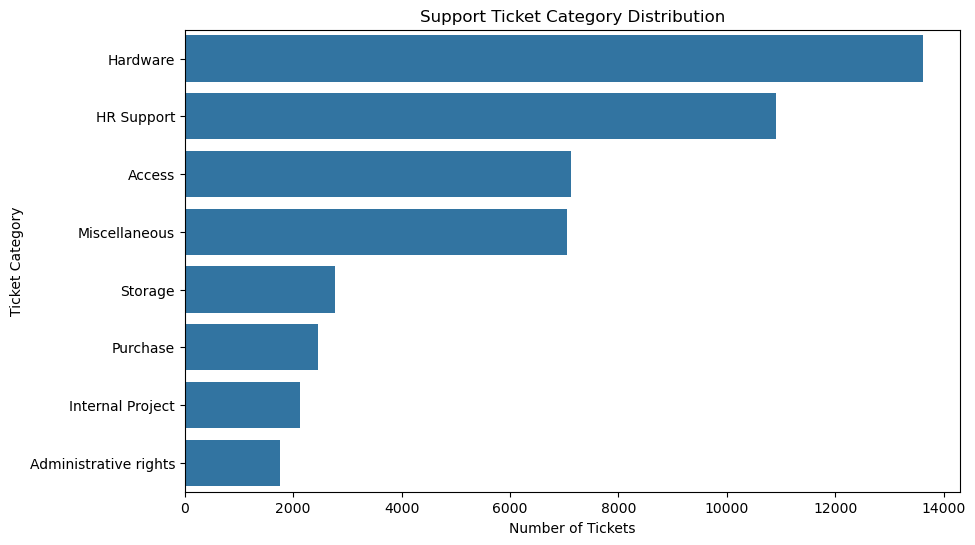

In [18]:
# Import plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(10,6))

# Plot category counts
sns.countplot(
    y=df['Topic_group'],
    order=df['Topic_group'].value_counts().index
)

# Title and labels
plt.title("Support Ticket Category Distribution")
plt.xlabel("Number of Tickets")
plt.ylabel("Ticket Category")

# Display plot
plt.show()

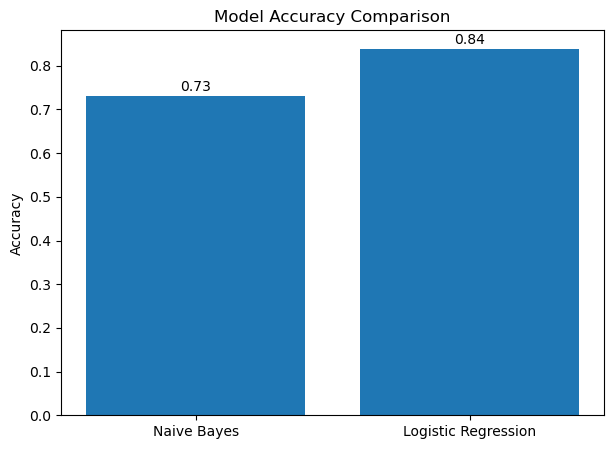

In [19]:
# Model names
models = ['Naive Bayes', 'Logistic Regression']

# Accuracy values
accuracies = [0.7314, 0.8392]

# Create figure
plt.figure(figsize=(7,5))

# Create bar plot
plt.bar(models, accuracies)

# Labels and title
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

# Display accuracy values on bars
for i, value in enumerate(accuracies):
    plt.text(i, value + 0.01, f"{value:.2f}", ha='center')

# Show plot
plt.show()

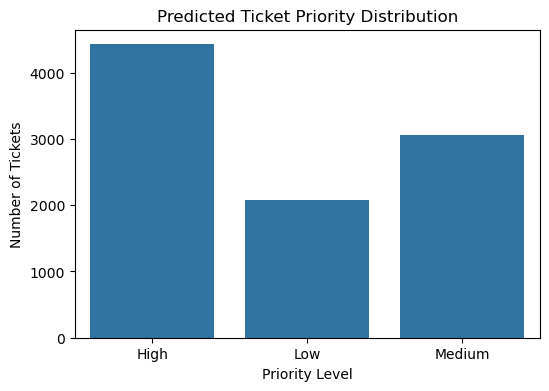

In [20]:
# Create figure
plt.figure(figsize=(6,4))

# Plot priority distribution
sns.countplot(x=predicted_priorities)

# Title and labels
plt.title("Predicted Ticket Priority Distribution")
plt.xlabel("Priority Level")
plt.ylabel("Number of Tickets")

# Show plot
plt.show()

** Final Project Conclusion **

This project successfully developed an NLP-based Support Ticket Classification System capable of automatically categorizing customer support tickets and assigning priority levels.

Initially, a Multinomial Naive Bayes model was implemented as a baseline classifier using TF-IDF vectorization. Although the model achieved reasonable performance, evaluation through the confusion matrix and classification report revealed class imbalance issues and bias toward dominant categories such as Hardware.

To address this limitation, a balanced Logistic Regression model using class_weight='balanced' was introduced. The improved model achieved approximately 84% accuracy and significantly improved recall and F1-scores for minority classes, resulting in a more balanced and reliable classification system.

The project also integrated a rule-based priority assignment mechanism that mapped predicted ticket categories to business-oriented urgency levels such as High, Medium, and Low priority. Additionally, an interactive prediction system was developed to allow real-time ticket classification and priority detection.

Overall, this project demonstrates practical applications of Natural Language Processing, machine learning model evaluation, imbalance handling, and business workflow automation in real-world support systems.